In [2]:
#import libraries
import numpy as np
from ase.io import read, write
from ase import Atoms
import torch
import yaml
import json
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys
import re
import functions as f #import functions used in this notebook

In [14]:
#variable setup
name = "Fe_Si_B_260311"
type = 'rnd_e'
#setting the model name based on model number and epochs
device = 'cpu'
model = "MACE-matpes-pbe-omat-ft"
model_id = 'matpes'
learning_rate = 1e-4
num_epoch = 40 #number of epochs used for training
batch_size = 10 #batch size for training
folder = f'{model_id}_{learning_rate}_{num_epoch}_{batch_size}_{type}'
trainin_file = f"model_{name}/train_{type}.xyz"
test_file = f"model_{name}/test_{type}.xyz"
os.makedirs(f'model_{name}/fine_tuning', exist_ok=True) #creates the main folder for the fine tunning
os.makedirs(f'model_{name}/fine_tuning/{folder}', exist_ok=True)
os.makedirs(f'model_{name}/fine_tuning/{folder}/img_res', exist_ok=True) #creates a folder to store the loss graphs
os.makedirs(f'model_{name}/fine_tuning/{folder}/test_res', exist_ok=True) #creates a folder to store the files of the testing of the model
''' model_name:
    generates the name of the model based on the number of epochs and the model number using the 'model_num' variable '''
model_name = f'model_{type}_{model_id}_lr{learning_rate}_{num_epoch}epochs_{batch_size}batch'
model_name

'model_rnd_e_matpes_lr0.0001_40epochs_10batch'

In [10]:
folder

'matpes_0.0001_40_10_rnd_e'

In [ ]:
#this writes the yml file
config = {
    'foundation_model': f'{model}.model',
    'multiheads_finetuning': False,
    "name": model_name,
    "model_dir": f"model_{name}/fine_tunning",
    "log_dir": f"model_{name}/fine_tunning/log",
    "checkpoints_dir": f"model_{name}/fine_tunning/checkpoints",
    "results_dir": f"model_{name}/fine_tunning/results",
    "train_file": trainin_file,
    "valid_fraction": 0.1,
    "test_file": test_file,
    "energy_key": "REF_energy",
    "forces_key": "REF_forces",
    "batch_size": batch_size,
    "max_num_epochs": num_epoch,
    "lr":learning_rate,
    "device": device,
    "seed": 123
}
with open(f"model_{name}/config_new_model.yml", "w") as f:
    yaml.dump(config, f, sort_keys=False)

In [15]:
#Perform training
import warnings
warnings.filterwarnings('ignore')
from mace.cli.run_train import main as mace_run_train_main
import sys
import logging

#defining the training function
def train_mace(config_file_path):
    logging.getLogger().handlers.clear()
    sys.argv = ['program', '--config', config_file_path]
    mace_run_train_main()

#calling the function
train_mace(f'model_{name}/config_new_model.yml') # use the name of the config file that was created

2026-03-31 15:20:03.183 INFO: ===========VERIFYING SETTINGS===========
2026-03-31 15:20:03.184 INFO: MACE version: 0.3.14
2026-03-31 15:20:03.185 INFO: Using CPU
2026-03-31 15:20:03.312 INFO: Using foundation model MACE-matpes-pbe-omat-ft.model as initial checkpoint.
2026-03-31 15:20:03.313 WARNING: Using multiheads finetuning with a foundation model that is not a Materials Project model, need to provied a path to a pretraining file with --pt_train_file.
2026-03-31 15:20:03.313 INFO: ===========LOADING INPUT DATA===========
2026-03-31 15:20:03.313 INFO: Using heads: ['Default']
2026-03-31 15:20:03.314 INFO: Using the key specifications to parse data:
2026-03-31 15:20:03.314 INFO: Default: KeySpecification(info_keys={'energy': 'REF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'REF_forces', 'cha

In [16]:
#reading the information on the results file
results = f'model_{name}/fine_tunning/results/{model_name}_run-123_train.txt' #reading the file where the training results is stored
data = [] #where the data from the 'results' file will be stored
with open(results, 'r') as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError:
            continue
results

'model_Fe_Si_B_260311/fine_tunning/results/model_rnd_e_MACE-matpes-pbe-omat-ft.model_lr0.0001_40epochs_10batch_run-123_train.txt'

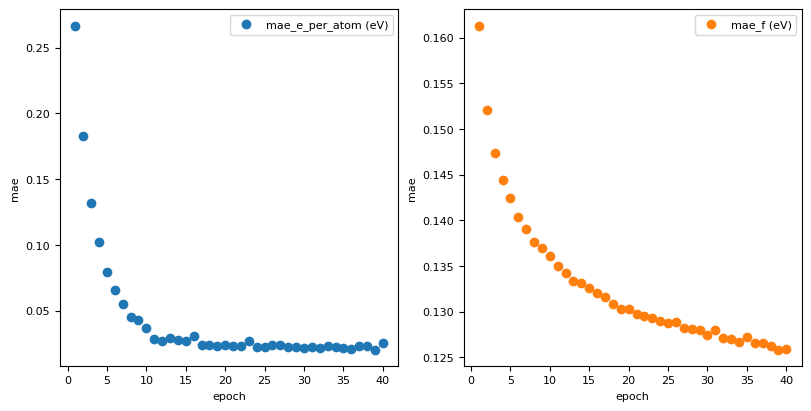

In [17]:
df = pd.DataFrame(data)
#separating the training and validation results
train_df = df[df['mode']=='opt'].copy()
val_df = df[df['mode']=='eval'].copy().dropna()
#train_df = train_df.groupby('epoch', as_index=False)['loss'].last()
train_df = train_df.groupby('epoch', as_index=False)['loss'].mean()
train_df['epoch'] += 1
val_df['epoch'] += 1

#plotting the dataframe
import functions as f
f.plot_mae(val_df, 'epoch', ['mae_e_per_atom','mae_f'])

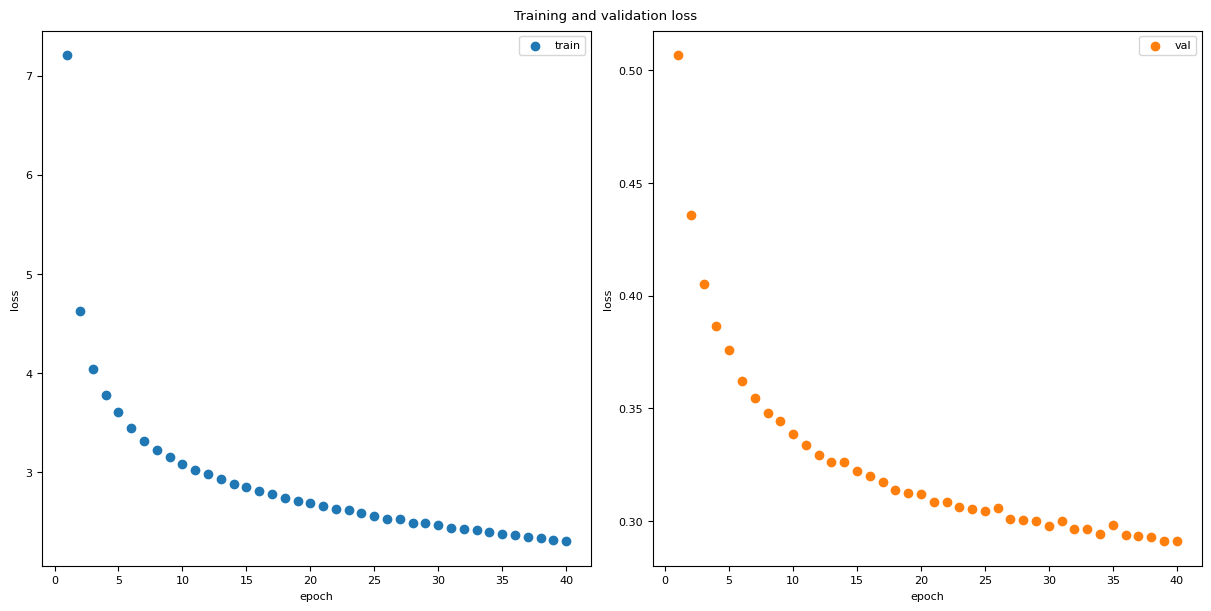

In [26]:
f.plot_loss([(train_df, 'train'),(val_df,'val')],'epoch','loss',model_name,name)

In [24]:
#evaluation
from mace.cli.eval_configs import main as mace_eval_configs_main
import sys

def eval_mace(model, configs, output, device=device):
    sys.argv=['program', '--configs', configs, '--model', model, '--output', output, '--device', device]
    mace_eval_configs_main()

#evaluating the set on both the training and test datasets
eval_mace(model=f'{model_id}',
          configs=f'model_{name}/train_{type}.xyz',
          output=f'model_{name}/fine_tunning/test_res/{model_name}_train.xyz')

eval_mace(model=f'{model_id}',
          configs=f'model_{name}/test_{type}.xyz',
          output=f'model_{name}/fine_tunning/test_res/{model_name}_test.xyz')

2026-04-01 15:30:09.716 INFO: Using CPU
2026-04-01 15:36:18.253 INFO: Using CPU


In [30]:
test_df = f.eval_read(name, model_id, 'test')
train_df = f.eval_read(name, model_id, 'train')
train_df = train_df[3:] #this is to not include the first three configuratiosn which are the isolated atoms
test_df1 = test_df[['n_atoms', 'REF_energy', 'MACE_energy', 'REF_e/atom_meV', 'MACE_e/atom_meV']].copy()
train_df1 = train_df[['n_atoms', 'REF_energy', 'MACE_energy', 'REF_e/atom_meV', 'MACE_e/atom_meV']].copy()
train_df2 = f.forces(train_df)
test_df2 = f.forces(test_df)

FileNotFoundError: [Errno 2] No such file or directory: 'model_Fe_Si_B_260311/test_res/MACE-matpes-pbe-omat-ft.model_test.xyz'